In [356]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Stroke Prediction Dataset

### Variables
1. **id**: unique identifier
2. **gender**: "Male", "Female" or "Other"
3. **age**: age of the patient
4. **hypertension**: `0` if the patient doesn't have hypertension, `1` if the patient has hypertension
5. **heart_disease**: `0` if the patient doesn't have any heart diseases, `1` if the patient has a heart disease
6. **ever_married**: "No" or "Yes"
7. **work_type**: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8. **Residence_type**: "Rural" or "Urban"
9. **avg_glucose_level**: average glucose level in blood
10. **bmi**: body mass index
11. **smoking_status**: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12. **stroke**: `1` if the patient had a stroke or `0` if not

In [357]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))
print(df.shape)
df.head(10)

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [358]:
#Making sure NaN values are being treated as missing values or string.
#There is also "unknown" on smoking_status, which are missing values.
print((df['bmi'] == 'NaN').sum())
df['smoking_status'] = df['smoking_status'].replace({'Unknown':0, 'smokes':2, 'formerly smoked':1, 'never smoked':-1})
df['smoking_status'] = df['smoking_status'].replace(0, np.nan)
df.isnull().sum()

0


id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

In [359]:
#Let's handle missing values in the 'bmi' and 'smoking_status' column using KNN imputation
imputer = KNNImputer()
df[['bmi']] = imputer.fit_transform(df[['bmi']]).round(2)
df[['smoking_status']] = imputer.fit_transform(df[['smoking_status']]).round(2)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,1.00,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89,-1.00,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,-1.00,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,2.00,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,-1.00,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.00,1.00,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.40,-1.00,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.80,-1.00,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.89,0.16,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.20,0.16,1


In [360]:
#Let's make it so hypertension and heart_disease are categorical and their value is a string instead of 0 and 1
#For future reference, try one hot coding.

df['hypertension'] = df['hypertension'].replace({0:'No', 1:'Yes'})
df['heart_disease'] = df['heart_disease'].replace({0:'No', 1:'Yes'})

#And now divide the variables into categorical (static) and numerical (continuous)

variables_numerical = ['age', 'avg_glucose_level', 'bmi']
variables_categorical = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

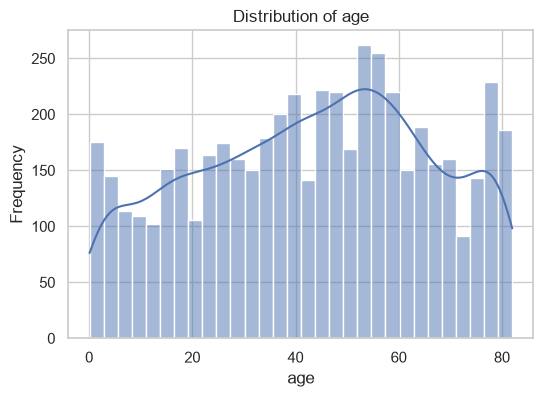

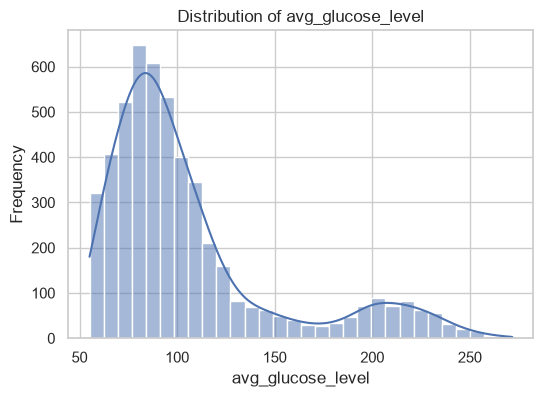

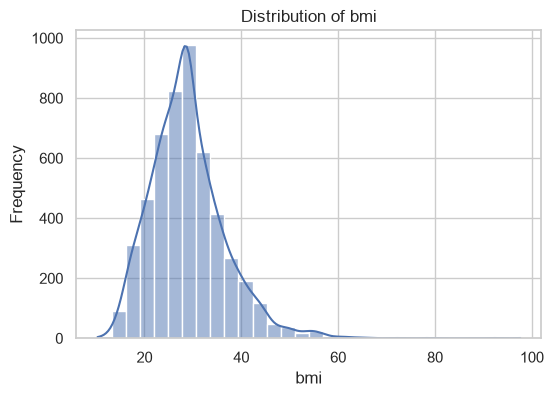

In [361]:
# We'll plot the variables to analyse the dataset we are working with

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

for col in variables_numerical:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

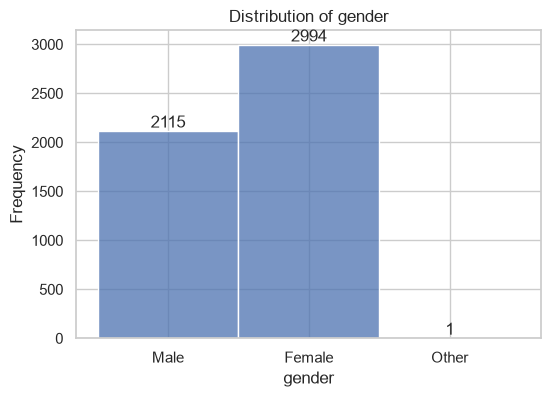

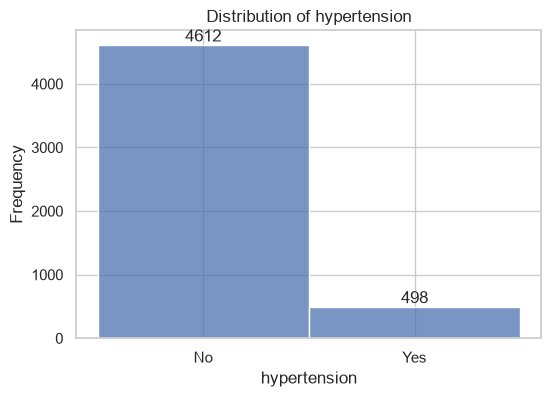

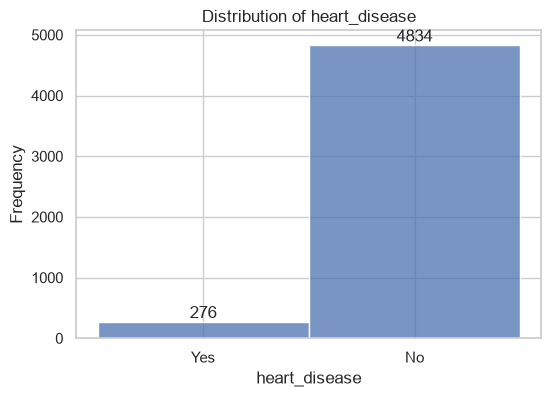

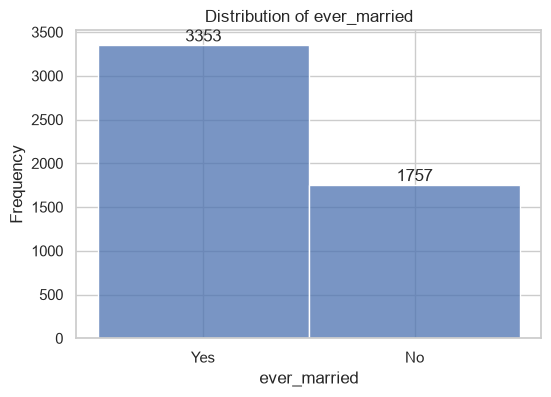

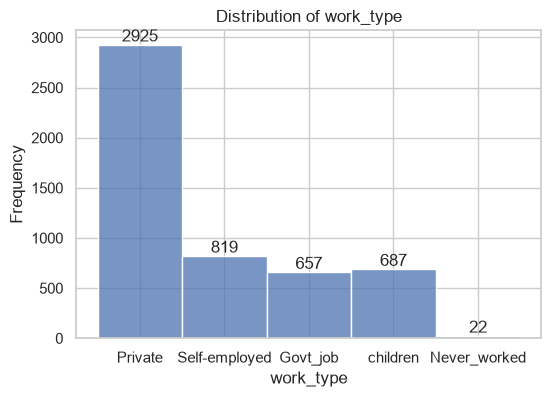

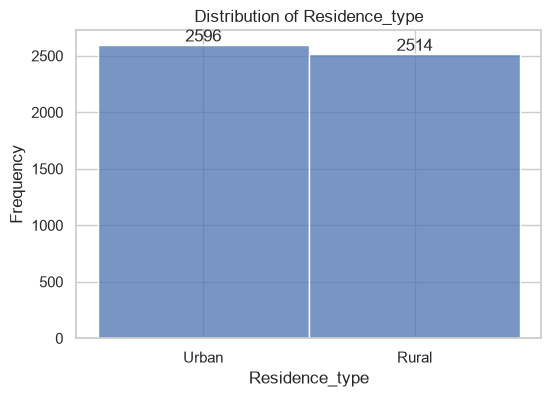

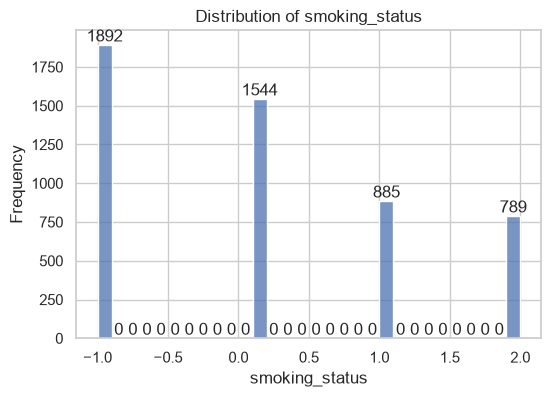

In [362]:
for col in variables_categorical:
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(data=df, x=col, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    for container in ax.containers:
        ax.bar_label(container)
    plt.show()

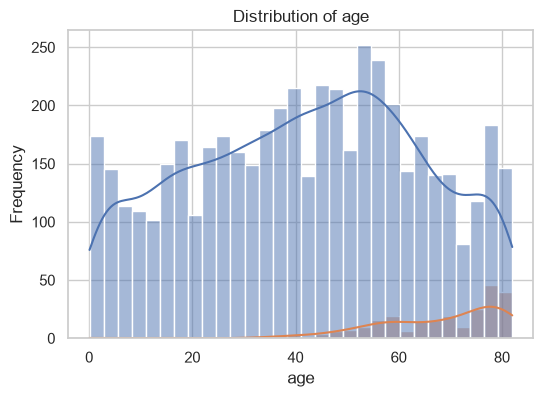

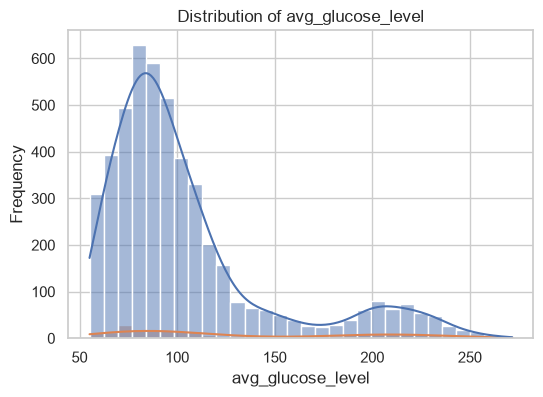

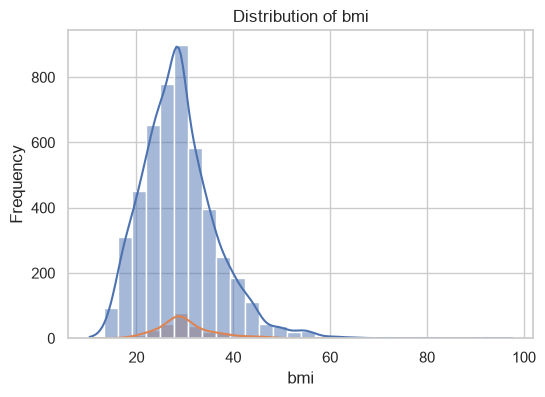

In [363]:
#Let's overlay the stroke variable on top of other variables to conclude if there looks to be a correlation

for col in variables_numerical:
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(data=df, x=col, bins=30, hue=df['stroke'], kde=True, legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

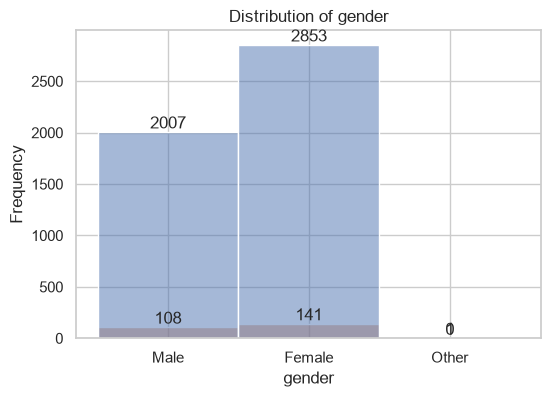

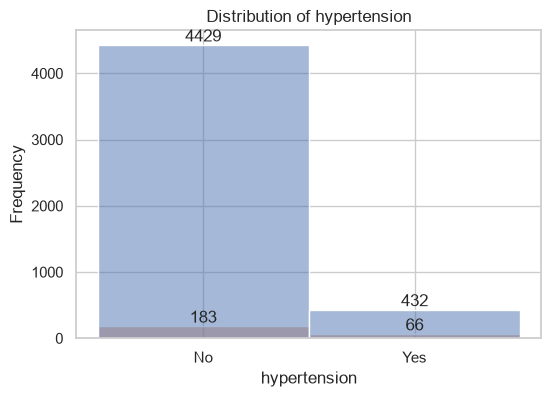

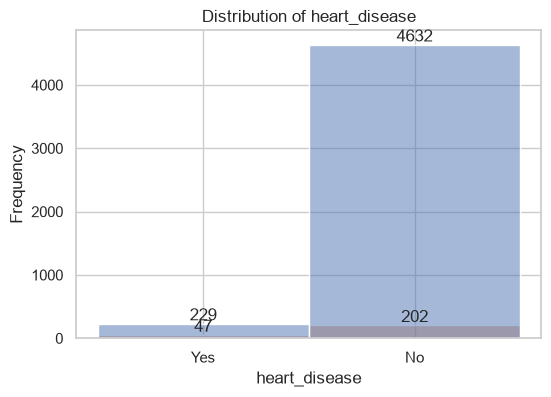

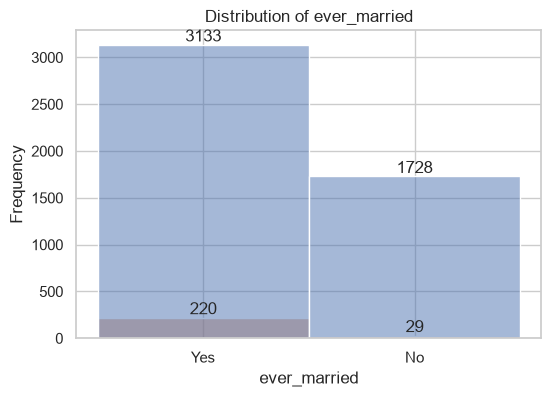

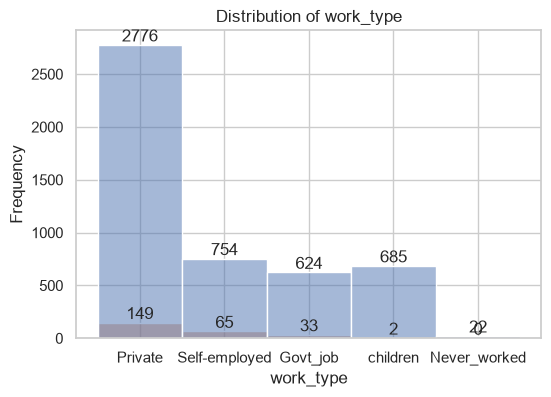

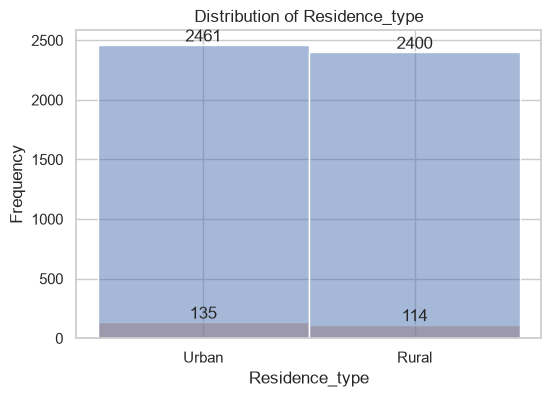

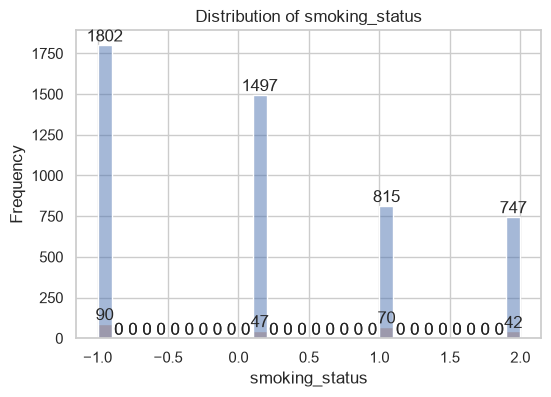

In [364]:
for col in variables_categorical:
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(data=df, x=col, bins=30, hue=df['stroke'], legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()

As we can see there seems to be a correlation between old age and the amount of strokes. Also we can clearly see on the other graphs their percentages seem to be equal.

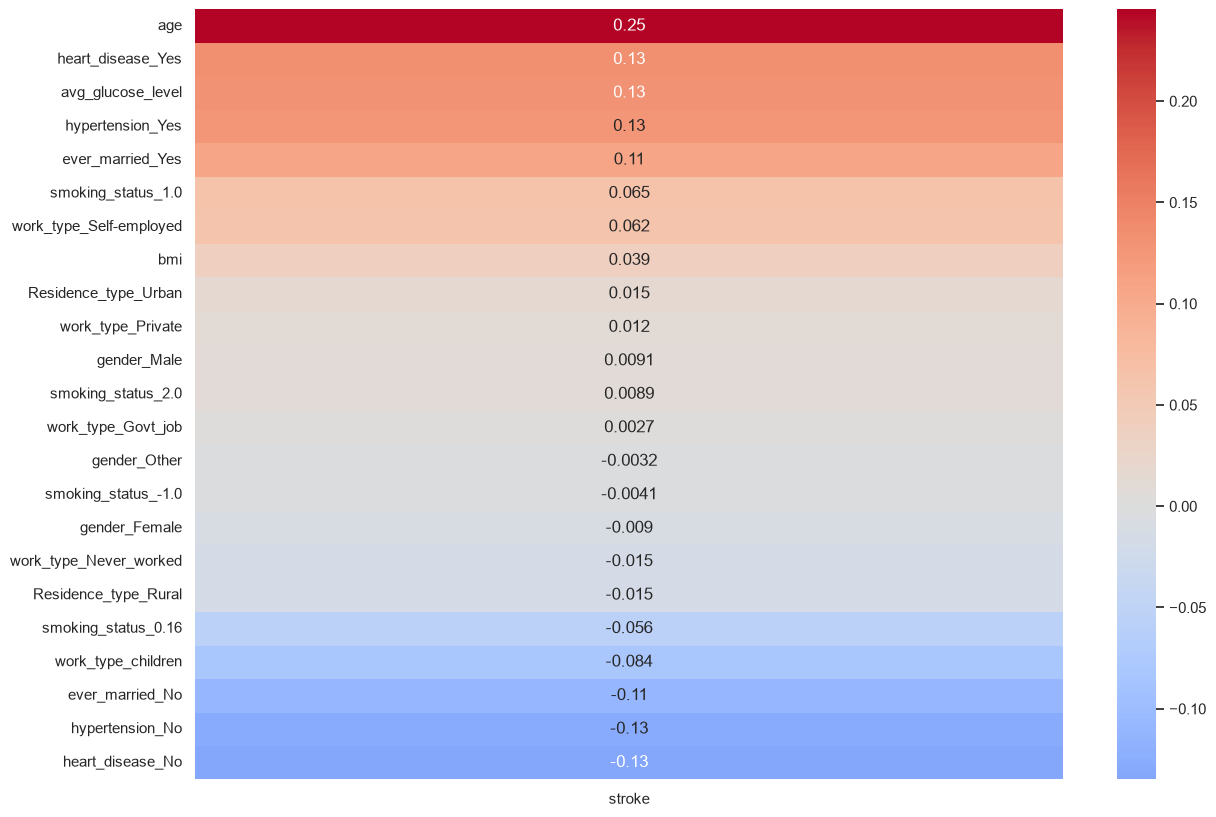

In [365]:
#Let's try an implementation of onehotenconder (used AI since I didn't quite understand), and make a correlation heatmap.

enc = OneHotEncoder(handle_unknown="ignore")

encoded = enc.fit_transform(df[variables_categorical])
encoded_df = pd.DataFrame(encoded.toarray(),
                          columns=enc.get_feature_names_out(variables_categorical),
                          index=df.index)

df_corr = pd.concat([df[variables_numerical + ["stroke"]], encoded_df], axis=1)

corr = df_corr.corr()

stroke_corr = (
    df_corr.corr()[["stroke"]].drop(index="stroke").sort_values(by="stroke", ascending=False))

plt.figure(figsize=(14, 10))
sns.heatmap(stroke_corr, cmap="coolwarm", center=0, annot=True)
plt.show()

As we can see the most relevant and correlated variables to having a stroke seem to be age, having a heart disease, hypertension and funnily having been married.

Average glucose level shouldn't be there in it's current state, I would need to separate their values into high/low first (I think?)

## Models

In [366]:
#It's important to avoid false positives since this would mean failing to identify possible strokes. Since the data is very imbalanced with mostly
# "no" strokes this will be a difficult task and must be handled carefully.

print((df['stroke'] == 0).sum())
print((df['stroke'] == 1).sum())

4861
249


In [367]:
#Let's make sure all variables are not in strings.
df['gender'] = df['gender'].replace({'Male':0,'Female':1,'Other':-1})
df['Residence_type'] = df['Residence_type'].replace({'Rural':0,'Urban':1})
df['work_type'] = df['work_type'].replace({'Private':0,'Self-employed':1,'Govt_job':2,'children':-1,'Never_worked':-2})
df['hypertension'] = df['hypertension'].replace({'No':0, 'Yes':1})
df['heart_disease'] = df['heart_disease'].replace({'No':0, 'Yes':1})
df['ever_married'] = df['ever_married'].replace({'No':0, 'Yes':1})
df['smoking_status'] = df['smoking_status'].replace({'Unknown':0, 'smokes':2, 'formerly smoked':1, 'never smoked':-1})
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,1,0,1,228.69,36.60,1.0,1
1,51676,1,61.0,0,0,1,1,0,202.21,28.89,-1.0,1
2,31112,0,80.0,0,1,1,0,0,105.92,32.50,-1.0,1
3,60182,1,49.0,0,0,1,0,1,171.23,34.40,2.0,1
4,1665,1,79.0,1,0,1,1,0,174.12,24.00,-1.0,1


In [368]:
df_prep = df.drop('id', axis=1)
df_ready = df.drop('stroke', axis=1)

X = df_ready
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)